RANDOM FOREST OPTIMISÉ - EXÉCUTION RAPIDE

📊 Dataset chargé: 140165 lignes, 16 colonnes

🔍 Aperçu des données:
   latitude  longitude   TEB_log  CEC_CLAY  GYPSUM_log  TEXTURE_SOTER_encoded  \
0  36.74886    6.25409  2.995732      53.0    1.960095                    3.0   
1  35.87978    4.44782  3.806662      48.0    2.208274                    3.0   
2  35.70751    5.53337  3.806662      48.0    2.208274                    3.0   
3  32.27667    3.98647  3.806662      71.0    2.028148                    3.0   
4  32.40079    4.00642  3.806662      71.0    2.028148                    3.0   

   ORG_CARBON_log  LCCCODE_encoded  ELEC_COND_log  COARSE  \
0        2.205193              1.0       1.945910    11.0   
1        2.099734              3.0       2.079442     5.0   
2        2.099734             16.0       2.079442     5.0   
3        2.040571             18.0       2.197225     3.0   
4        2.040571              3.0       2.197225     3.0   

   TEXTURE_USDA_encoded  class     

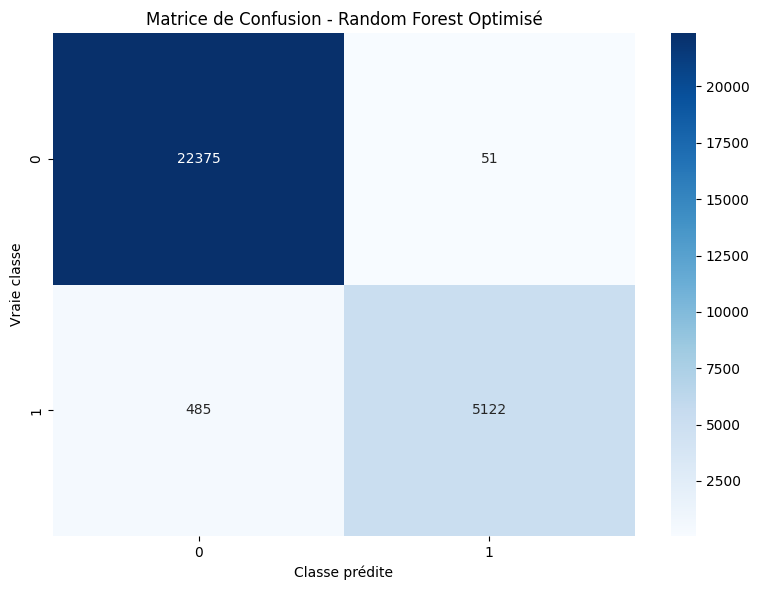

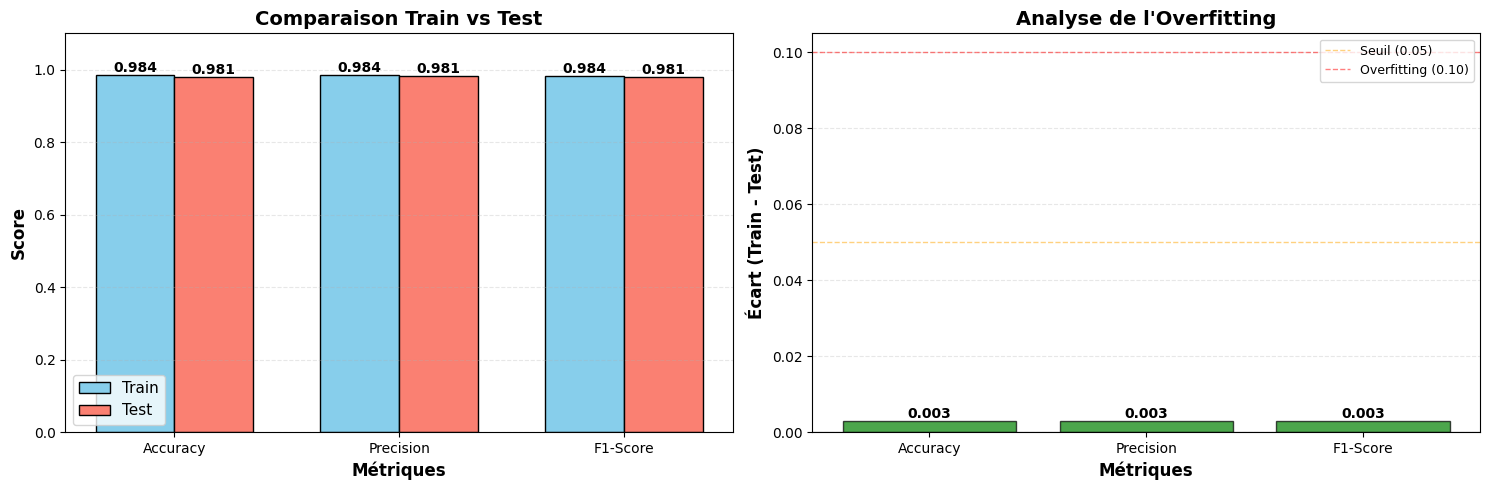

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
from datetime import datetime

# ========================================
# PARTIE 1: RANDOM FOREST FROM SCRATCH 
# ========================================

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      
        self.threshold = threshold  
        self.left = left           
        self.right = right         
        self.value = value         

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.root = None
    
    def fit(self, X, y):
       
        self.n_features = X.shape[1]
        if self.max_features is None:
            self.max_features = int(np.sqrt(self.n_features))
        self.root = self._grow_tree(X, y)
    
    def _gini_impurity(self, y):
       
        proportions = np.bincount(y) / len(y)
        return 1 - np.sum(proportions ** 2)
    
    def _split(self, X, y, feature, threshold):
       
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]
    
    def _best_split(self, X, y):
       
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        # Sélectionner aléatoirement un sous-ensemble de features
        features = np.random.choice(self.n_features, self.max_features, replace=False)
        
        for feature in features:
            unique_vals = np.unique(X[:, feature])
            if len(unique_vals) > 10:
                indices = np.linspace(0, len(unique_vals)-1, 10, dtype=int)
                thresholds = unique_vals[indices]
            else:
                thresholds = unique_vals
            
            for threshold in thresholds:
                X_left, X_right, y_left, y_right = self._split(X, y, feature, threshold)
                
                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue
                
                gini_parent = self._gini_impurity(y)
                n = len(y)
                n_left, n_right = len(y_left), len(y_right)
                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)
                
                gain = gini_parent - (n_left/n * gini_left + n_right/n * gini_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _grow_tree(self, X, y, depth=0):
        
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
       
        if (depth >= self.max_depth or 
            n_labels == 1 or 
            n_samples < self.min_samples_split):
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
       
        best_feature, best_threshold = self._best_split(X, y)
        
        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
       
        X_left, X_right, y_left, y_right = self._split(X, y, best_feature, best_threshold)
        left = self._grow_tree(X_left, y_left, depth + 1)
        right = self._grow_tree(X_right, y_right, depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)
    
    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])


class RandomForest:
    def __init__(self, n_estimators=100, max_depth=10, min_samples_split=2, 
                 min_samples_leaf=1, max_features=None, bootstrap=True):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.trees = []
    
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]
    
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features
            )
            
            if self.bootstrap:
                X_sample, y_sample = self._bootstrap_sample(X, y)
            else:
                X_sample, y_sample = X, y
            
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    
    def predict(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        # Vote majoritaire
        predictions = []
        for i in range(X.shape[0]):
            votes = tree_predictions[:, i]
            predictions.append(Counter(votes).most_common(1)[0][0])
        return np.array(predictions)
    
    def predict_proba(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        n_samples = X.shape[0]
        n_classes = len(np.unique(tree_predictions))
        
        probas = np.zeros((n_samples, n_classes))
        for i in range(n_samples):
            votes = tree_predictions[:, i]
            for cls in range(n_classes):
                probas[i, cls] = np.sum(votes == cls) / self.n_estimators
        
        return probas


# ========================================
# PARTIE 2: CHARGEMENT ET PRÉPARATION
# ========================================

start_time = time.time()

print("=" * 60)
print("RANDOM FOREST OPTIMISÉ - EXÉCUTION RAPIDE")
print("=" * 60)

# Charger les données
df = pd.read_csv(r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv")
print(f"\n📊 Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Afficher les premières lignes
print("\n🔍 Aperçu des données:")
print(df.head())

# Vérifier les valeurs manquantes
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\n❌ Valeurs manquantes détectées - Suppression des lignes:")
    print(missing[missing > 0])
    df = df.dropna()
    print(f"✅ Dataset après nettoyage: {df.shape[0]} lignes")

# Séparer features et target
TARGET_COLUMN = 'class'  # ← Modifier si nécessaire

if TARGET_COLUMN in df.columns:
    print(f"\n✅ Colonne target '{TARGET_COLUMN}' trouvée!")
    y = df[TARGET_COLUMN]
    X = df.drop(TARGET_COLUMN, axis=1)
elif 'target' in df.columns:
    print(f"\n✅ Colonne 'target' trouvée!")
    y = df['target']
    X = df.drop('target', axis=1)
else:
    print(f"\n⚠️ Colonne '{TARGET_COLUMN}' non trouvée, utilisation de la dernière colonne")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

print(f"\n✅ Features: {X.shape[1]} colonnes")
print(f"✅ Distribution des classes: {Counter(y)}")

# Normalisation
print("\n🔄 Normalisation...")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("✅ Normalisation terminée")

# ========================================
# PARTIE 3: SPLIT DES DONNÉES
# ========================================

print("\n" + "=" * 60)
print("PRÉPARATION DES DONNÉES")
print("=" * 60)

# Vérifier la distribution des classes
class_counts = Counter(y)
min_samples_per_class = 2
rare_classes = [cls for cls, count in class_counts.items() if count < min_samples_per_class]

if rare_classes:
    print(f"\n⚠️ Suppression des classes rares: {rare_classes}")
    mask = ~y.isin(rare_classes)
    X_scaled = X_scaled[mask]
    y = y[mask]
    print(f"   ✅ Dataset réduit: {len(y)} échantillons")

# Split avec stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled.values, y.values, 
    test_size=0.2, random_state=42, stratify=y
)

print(f"\n📦 Train: {X_train.shape[0]} échantillons")
print(f"📦 Test: {X_test.shape[0]} échantillons")


# ========================================
# PARTIE 4: OPTIMISATION BAYÉSIENNE
# ========================================

print("\n" + "=" * 60)
print("OPTIMISATION BAYÉSIENNE (ACCÉLÉRÉE)")
print("=" * 60)

# Wrapper pour sklearn compatibility
from sklearn.base import BaseEstimator, ClassifierMixin

class RandomForestScratch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=50, max_depth=10, min_samples_split=2, 
                 min_samples_leaf=1, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.rf = None
    
    def fit(self, X, y):
        self.rf = RandomForest(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features
        )
        self.rf.fit(X, y)
        return self
    
    def predict(self, X):
        return self.rf.predict(X)
    
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

# ESPACE DE RECHERCHE RÉDUIT (pour rapidité)
search_spaces = {
    'n_estimators': Integer(30, 60),      
    'max_depth': Integer(8, 15),         
    'min_samples_split': Integer(5, 10),  
    'min_samples_leaf': Integer(2, 4),   
    'max_features': Integer(4, 8)         
}

print("\n🔍 Espace de recherche (optimisé):")
for param, space in search_spaces.items():
    print(f"   {param}: {space}")

# Optimisation Bayésienne ACCÉLÉRÉE
print("\n⏳ Lancement de l'optimisation (~ 15-25 min)...")
opt_start = time.time()

bayes_search = BayesSearchCV(
    RandomForestScratch(),
    search_spaces,
    n_iter=5,           
    cv=2,               
    n_jobs=-1,         
    verbose=2,         
    random_state=42,
    scoring='accuracy'
)
bayes_search.fit(X_train, y_train)

opt_time = time.time() - opt_start
print(f"\n✅ Optimisation terminée en {opt_time/60:.2f} minutes!")

print("\n🏆 Meilleurs hyperparamètres:")
for param, value in bayes_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Meilleur score CV: {bayes_search.best_score_:.4f}")

# SAUVEGARDER TOUS LES RÉSULTATS DE L'OPTIMISATION
results_df = pd.DataFrame(bayes_search.cv_results_)
results_df['rank'] = results_df['rank_test_score']
results_df = results_df.sort_values('rank_test_score')

# Sélectionner les colonnes importantes
cols_to_save = [col for col in results_df.columns if col.startswith('param_') or 
                col in ['mean_test_score', 'std_test_score', 'rank_test_score', 'mean_fit_time']]
results_summary = results_df[cols_to_save].head(10)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_summary.to_csv(f'bayesian_optimization_results_{timestamp}.csv', index=False)
print(f"\n💾 Résultats d'optimisation sauvegardés: bayesian_optimization_results_{timestamp}.csv")


# ========================================
# PARTIE 5: ENTRAÎNEMENT FINAL ET ÉVALUATION
# ========================================

print("\n" + "=" * 60)
print("ENTRAÎNEMENT DU MODÈLE FINAL")
print("=" * 60)

# Entraîner avec les meilleurs paramètres
train_start = time.time()
best_rf = RandomForest(**bayes_search.best_params_)
best_rf.fit(X_train, y_train)
train_time = time.time() - train_start
print(f"✅ Entraînement terminé en {train_time:.2f} secondes")

# Prédictions
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

# Métriques
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_precision = precision_score(y_train, y_pred_train, average='weighted')
test_precision = precision_score(y_test, y_pred_test, average='weighted')
train_f1 = f1_score(y_train, y_pred_train, average='weighted')
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

print(f"\n📈 MÉTRIQUES:")
print(f"{'Métrique':<15} {'Train':<10} {'Test':<10} {'Gap':<10}")
print("-" * 50)
print(f"{'Accuracy':<15} {train_acc:<10.4f} {test_acc:<10.4f} {train_acc-test_acc:<10.4f}")
print(f"{'Precision':<15} {train_precision:<10.4f} {test_precision:<10.4f} {train_precision-test_precision:<10.4f}")
print(f"{'F1-Score':<15} {train_f1:<10.4f} {test_f1:<10.4f} {train_f1-test_f1:<10.4f}")

# SAUVEGARDER LES MÉTRIQUES EN CSV
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'F1-Score'],
    'Train': [train_acc, train_precision, train_f1],
    'Test': [test_acc, test_precision, test_f1],
    'Gap': [train_acc-test_acc, train_precision-test_precision, train_f1-test_f1]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(f'final_metrics_{timestamp}.csv', index=False)
print(f"\n💾 Métriques finales sauvegardées: final_metrics_{timestamp}.csv")

# Classification Report
print("\n📊 Classification Report (Test):")
print(classification_report(y_test, y_pred_test))

# Sauvegarder le rapport de classification
report_dict = classification_report(y_test, y_pred_test, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(f'classification_report_{timestamp}.csv')
print(f"💾 Rapport de classification sauvegardé: classification_report_{timestamp}.csv")

# ========================================
# PARTIE 6: VISUALISATIONS
# ========================================

print("\n" + "=" * 60)
print("GÉNÉRATION DES VISUALISATIONS")
print("=" * 60)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - Random Forest Optimisé')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.savefig(f'confusion_matrix_{timestamp}.png', dpi=300, bbox_inches='tight')
print("✅ Matrice de confusion sauvegardée")

# Comparaison Train vs Test
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics_names = ['Accuracy', 'Precision', 'F1-Score']
train_scores = [train_acc, train_precision, train_f1]
test_scores = [test_acc, test_precision, test_f1]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_scores, width, label='Train', color='skyblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, test_scores, width, label='Test', color='salmon', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_xlabel('Métriques', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Comparaison Train vs Test', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend(fontsize=11)
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Gap d'overfitting
gaps = [train_acc - test_acc, train_precision - test_precision, train_f1 - test_f1]
colors = ['red' if gap > 0.1 else 'orange' if gap > 0.05 else 'green' for gap in gaps]

bars = axes[1].bar(metrics_names, gaps, color=colors, edgecolor='black', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=10, fontweight='bold')

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].axhline(y=0.05, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Seuil (0.05)')
axes[1].axhline(y=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Overfitting (0.10)')

axes[1].set_xlabel('Métriques', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Écart (Train - Test)', fontsize=12, fontweight='bold')
axes[1].set_title('Analyse de l\'Overfitting', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'overfitting_analysis_{timestamp}.png', dpi=300, bbox_inches='tight')
print("✅ Graphiques d'overfitting sauvegardés")

# ========================================
# RÉSUMÉ FINAL
# ========================================

total_time = time.time() - start_time

print("\n" + "=" * 60)
print("✅ EXÉCUTION TERMINÉE!")
print("=" * 60)
print(f"\n⏱️  Temps total: {total_time/60:.2f} minutes")
print(f"   - Optimisation bayésienne: {opt_time/60:.2f} min")
print(f"   - Entraînement final: {train_time:.2f} sec")
print(f"\n📊 Performance finale:")
print(f"   - Test Accuracy: {test_acc:.4f}")
print(f"   - Test F1-Score: {test_f1:.4f}")
print(f"   - Overfitting Gap: {max(gaps):.4f}")

print(f"\n💾 Fichiers sauvegardés:")
print(f"   - bayesian_optimization_results_{timestamp}.csv")
print(f"   - final_metrics_{timestamp}.csv")
print(f"   - classification_report_{timestamp}.csv")
print(f"   - confusion_matrix_{timestamp}.png")
print(f"   - overfitting_analysis_{timestamp}.png")

# Interprétation automatique
max_gap = max(gaps)
print("\n🔍 INTERPRÉTATION:")
if max_gap > 0.15:
    print("❌ OVERFITTING SÉVÈRE - Réduire la complexité du modèle")
elif max_gap > 0.08:
    print("⚠️ OVERFITTING MODÉRÉ - Ajuster les hyperparamètres")
elif max_gap > 0.03:
    print("✅ LÉGÈRE SURADAPTATION - Acceptable")
else:
    print("✅ EXCELLENT - Pas d'overfitting!")

print("\n" + "=" * 60)